In [1]:
!pip install opencv-python matplotlib

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import time
from multiprocessing.dummy import Pool  # ThreadPool

ModuleNotFoundError: No module named 'cv2'

In [3]:
from google.colab import files
uploaded = files.upload()

Saving Screenshot 2026-03-25 120956.png to Screenshot 2026-03-25 120956.png


In [4]:
img = cv2.imread(list(uploaded.keys())[0])
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

In [5]:
start = time.time()

for _ in range(20):  # repeat to increase workload
    denoised = cv2.GaussianBlur(img, (21,21), 0)
    gray = cv2.cvtColor(denoised, cv2.COLOR_RGB2GRAY)
    _, segmented = cv2.threshold(gray, 127, 255, cv2.THRESH_BINARY)
    edges = cv2.Canny(gray, 50, 150)

end = time.time()

print("Sequential Time:", end - start)

Sequential Time: 0.5580570697784424


Parallel Time: 0.2549901008605957


(np.float64(-0.5), np.float64(1341.5), np.float64(652.5), np.float64(-0.5))

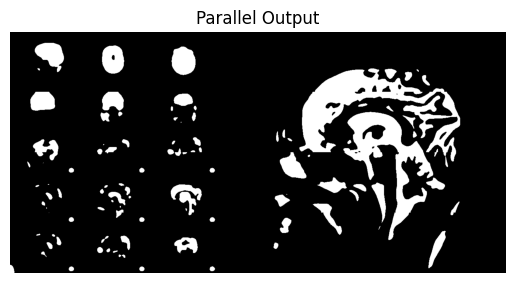

In [6]:
def process_part(initial_part_rgb):
    last_segmented_output = None
    for _ in range(20):  # same workload
        denoised_part = cv2.GaussianBlur(initial_part_rgb, (21,21), 0)
        gray = cv2.cvtColor(denoised_part, cv2.COLOR_RGB2GRAY)
        _, last_segmented_output = cv2.threshold(gray, 127, 255, cv2.THRESH_BINARY)
    return last_segmented_output

parts = np.array_split(img, 4)

start = time.time()

with Pool(4) as p:
    results = p.map(process_part, parts)

final = np.vstack(results)

end = time.time()

print("Parallel Time:", end - start)

plt.imshow(final, cmap='gray')
plt.title("Parallel Output")
plt.axis('off')